# Autocorrelation Analysis
We again consider the Lorenz system $$\begin{align}\frac{dx}{dt} &= \sigma(y-x)\\\frac{dy}{dt} &= -xz + rx - y\\\frac{dz}{dt} &= xy - bz,\end{align}$$ with paramters $\sigma = 10$, $r = 28$, and $b=\frac{8}{3}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# runge-kutta fourth-order integrator
def rk4(f, t0, tf, x0, dt, substeps=4, f_args=()):
    t = np.arange(t0, tf + dt, dt)
    x = np.empty((t.size, len(x0)), dtype=float)
    x[0] = np.array(x0, dtype=float)
    h = dt / substeps

    # integrate
    for n in range(t.size - 1):
        tn = t[n]
        xn = x[n].copy()
        # internal substeps for stability/accuracy
        for _ in range(substeps):
            k1 = f(tn, xn, *f_args)
            k2 = f(tn + 0.5 * h, xn + 0.5 * h * k1, *f_args)
            k3 = f(tn + 0.5 * h, xn + 0.5 * h * k2, *f_args)
            k4 = f(tn + h, xn + h * k3, *f_args)
            xn = xn + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
            tn = tn + h
        x[n + 1] = xn

    return t, x

In [3]:
# lorenz attractor eqns
def lorenz(t, x, sigma, r, b):
    dx_dt = sigma * (x[1] - x[0])
    dy_dt = x[0] * (r - x[2]) - x[1]
    dz_dt = x[0] * x[1] - b * x[2]
    return np.array([dx_dt, dy_dt, dz_dt], dtype=float)

### Sampling of dynamics

In [ ]:
sigma, r, b = 10, 28, 8/3
x0 = np.array([1.0, 3.0, 2.0])
dt = 0.01
sample_dt = 0.05
step = int(sample_dt/dt)

# integrate long enough to allow transients to decay
t0, tf = 0.0, 100.0
t, x = rk4(lorenz, t0, tf, x0, dt, f_args=(sigma, r, b))

# discard first 50 seconds, then sample 1000 equally spaced points
start = int(50.0/dt)
Xn = x[start:start + 1000 * step:step, 0]
print('number of sampled points:', len(Xn))

number of sampled points: 1000


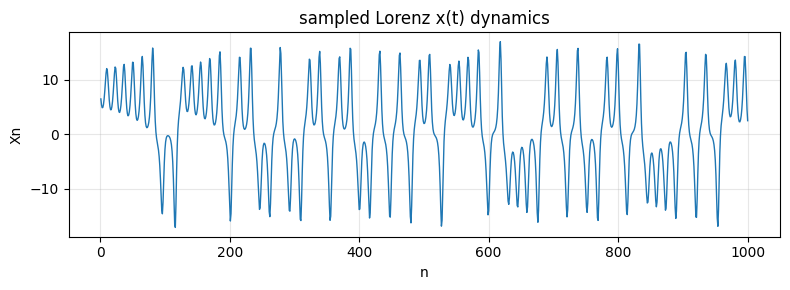

In [5]:
plt.figure(figsize=(8, 3))
plt.plot(np.arange(1, len(Xn) + 1), Xn, lw=1.0)
plt.xlabel('n')
plt.ylabel('Xn')
plt.title('sampled Lorenz x(t) dynamics')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Autocorrelation of sampled dynamics
We now compute the autocorrelation function
$$\begin{equation*}G(k) \approx \frac{\sum_{n=1}^{N-k}(X_n-\langle X\rangle)(X_{n+k}-\langle X\rangle)}{\sum_{n=1}^{N-k}(X_n-\langle X\rangle)^2},\end{equation*}$$
where $\langle X\rangle = \frac{1}{N}\sum_{n=1}^{N}X_n$. We report the time $G(k)$ falls below $\frac{1}{e}$ as the correlation time.

In [6]:
def autocorrelation(X, kmax=None):
    X = np.asarray(X, dtype=float)
    N = X.size
    if kmax is None:
        kmax = N-1
    kmax = min(kmax,N-1)
    X_mean = np.mean(X)
    G = np.empty(kmax+1, dtype=float)
    for k in range(kmax + 1):
        x1 = X[:N-k] - X_mean
        x2 = X[k:] - X_mean
        G[k] = np.sum(x1 * x2) / np.sum(x1 * x1)
    return G

In [ ]:
def first_crossing_below(y, level):
    idx = np.where(y <= level)[0]
    if len(idx) == 0:
        return None
    j = idx[0]
    if j == 0:
        return float(j)
    # linear interpolation between j-1 and j
    x0, x1 = j - 1, j
    y0, y1 = y[x0], y[x1]
    return x0 + (level-y0)/(y1-y0)

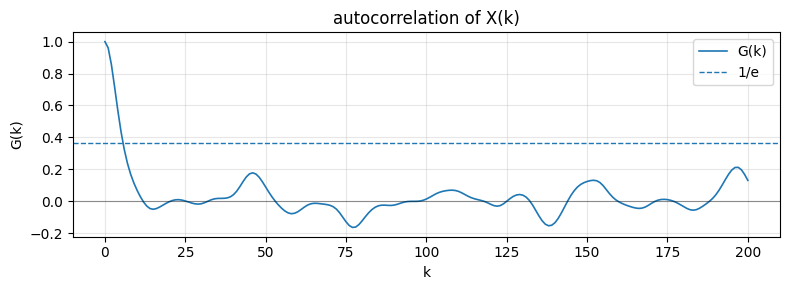

first integer k with G(k) <= 1/e: k = 6
interpolated crossing: k ≈ 5.623
autocorrelation time from integer lag: tau_c ≈ 0.300 s
autocorrelation time from interpolation: tau_c ≈ 0.281 s


In [15]:
kmax = 200
G = autocorrelation(Xn, kmax=kmax)
ks = np.arange(kmax + 1)

plt.figure(figsize=(8, 3))
plt.plot(ks, G, lw=1.2, label='G(k)')
plt.axhline(1/np.e, ls='--', lw=1.0, label='1/e')
plt.axhline(0.0, color='k', lw=0.8, alpha=0.4)
plt.xlabel('k')
plt.ylabel('G(k)')
plt.title('autocorrelation of X(k)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

level = 1 / np.e
k_int = np.where(G <= level)[0][0]
k_est = first_crossing_below(G, level)
tau_int = k_int * sample_dt
tau_est = k_est * sample_dt

print(f'first integer k with G(k) <= 1/e: k = {k_int}')
print(f'interpolated crossing: k ≈ {k_est:.3f}')
print(f'autocorrelation time from integer lag: tau_c ≈ {tau_int:.3f} s')
print(f'autocorrelation time from interpolation: tau_c ≈ {tau_est:.3f} s')

### Autocorrelation of other time series

In [61]:
def logistic_map(x, a=1.0):
    return a * x * (1 - x)

def logistic_series(x0, n, a=1.0):
    xs = [x0]
    for _ in range(n):
        xi = logistic_map(xs[-1], a=a)
        xs.append(xi)
    return np.asarray(xs)

In [62]:
N = 10000
kmax = 100
n = np.arange(N)
np.random.seed(0)

series_dict = {
    'sine wave at 7 Hz': np.sin(2 * np.pi * 7 * n * sample_dt), # 7 Hz
    'uniform random sequence': np.random.rand(N),
    'logistic map (A=4)': logistic_series(0.123456, N-1, a=4.0),
    'two incommensurate sine waves': (
        np.sin(2 * np.pi * 7 * sample_dt * n) + # 7 Hz
        np.sin(2 * np.pi * np.sqrt(20) * sample_dt * n) # ~4.47 Hz
    ),
    'Gaussian random sequence': np.random.randn(N)
}

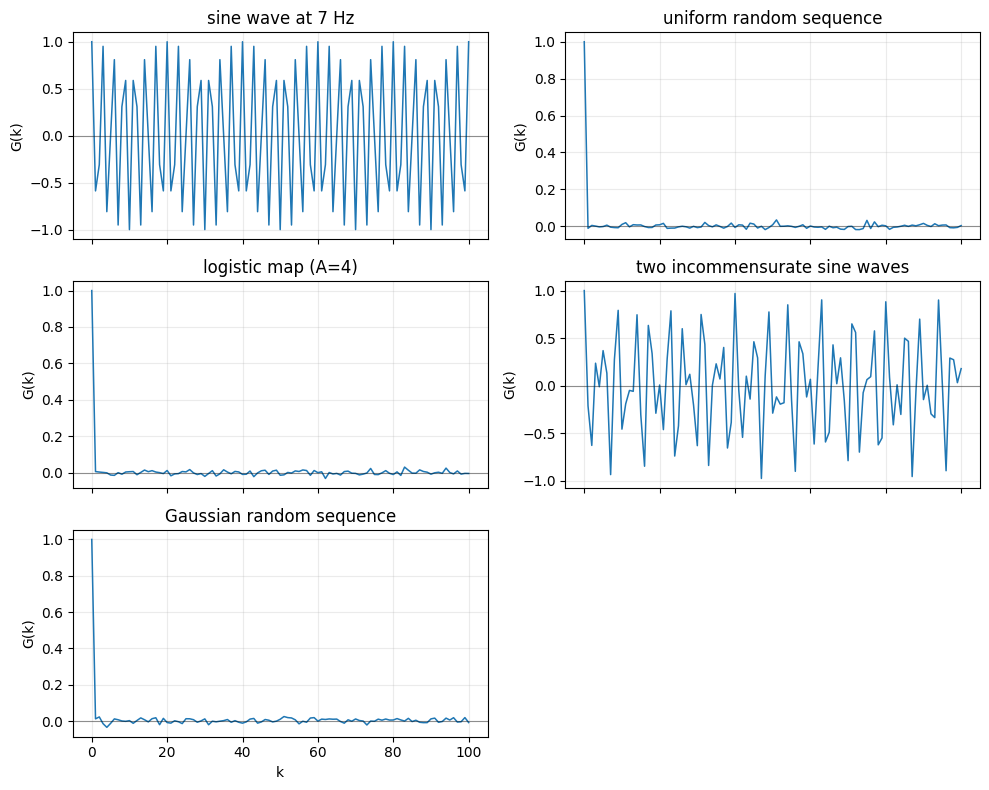

In [63]:
fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharex=True)
axes = axes.ravel()
for ax, (title, X) in zip(axes, series_dict.items()):
    G = autocorrelation(X, kmax=kmax)
    ax.plot(np.arange(kmax + 1), G, lw=1.1)
    ax.axhline(0.0, color='k', lw=0.8, alpha=0.4)
    ax.set_title(title)
    ax.set_ylabel('G(k)')
    ax.grid(alpha=0.25)
axes[4].set_xlabel('k')
axes[5].set_xlabel('k')
axes[-1].axis('off')
plt.tight_layout()
plt.show()